In [35]:
import numpy as np
import torch
import gpytorch
from matplotlib import pyplot as plt
import pandas as pd
from scipy import interpolate
import random

In [36]:
putts = pd.read_csv("/Users/federicadomecq/Documents/golfModeL47-1/PART 1/broadiedata/strokes_on_green_feet_broadie.csv")
columns = putts.columns
print(columns)

Index(['Distance (feet)', 'Green'], dtype='object')


# Interpolating expected putts

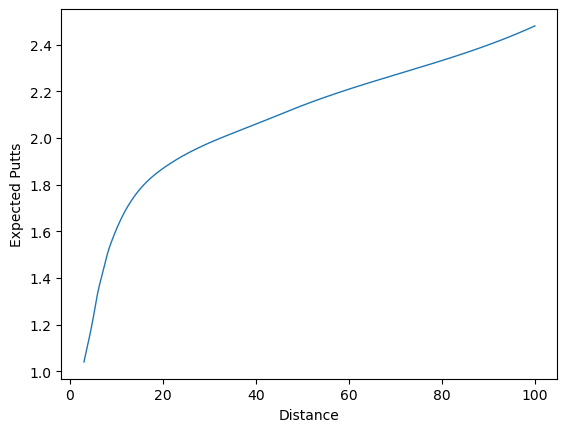

In [37]:
dist, avg_putts = putts["Distance (feet)"], putts["Green"]
expected_putts = interpolate.interp1d(dist, avg_putts, kind = "cubic", fill_value = "extrapolate")
x_true = np.linspace(min(dist), max(dist) + 10, 500)
y_true = expected_putts(x_true)
plt.plot(x_true, y_true, label = "true function", linewidth = 1 )
plt.xlabel("Distance")
plt.ylabel("Expected Putts")
plt.show()

# Simulating Fake Data

Generating data. The average number of events in a PGA tour season is 39. So generating 35 different observations max at any point... fewer observations the longer the putt.
Simulating recorded tournament average putts at different distances (feet).
For each distance $d\in [1,100]$ I'm going to generate a number of samples:
- $n_d = 35, d \leq 30 $
- $n_d$ decreases smoothly as $d \to 100$

Defining sampling frequency:

Text(0, 0.5, 'Average putts to hole out')

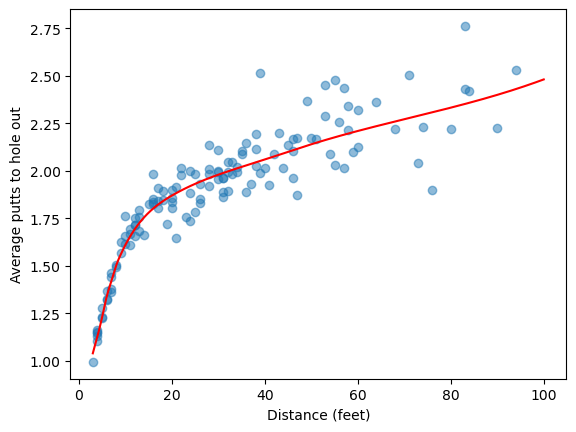

In [38]:
random.seed(47)
def samples_at(dist):
        decay_rate = 0.04  # tweak this!
        p = 1 / (1 + np.exp(decay_rate * (dist - 20))) 
        return np.random.binomial(n=5, p=p)
    
def noise_sd(d):
    return min(0.0028 * d + 0.02, 1.2)

simulated_averages = []
for distance in range(3,100):
    current_expected = expected_putts(distance)
    current_variance = noise_sd(d = distance)
    n_samples = samples_at(distance)
    for samples in range(n_samples):
        simulated_averages.append((distance, np.random.normal(current_expected, current_variance)))

xs_sim_distance = []
ys_sim_average = []

for pair in simulated_averages:
    distance, average = pair
    xs_sim_distance.append(distance)
    ys_sim_average.append(average)

plt.scatter(xs_sim_distance, ys_sim_average, alpha = .5)
plt.plot(x_true, y_true, color = "red")
plt.xlabel("Distance (feet)")
plt.ylabel("Average putts to hole out")

# Implementing GPR using GPyTorch

## Format data into 2d

In [39]:
train_x = torch.tensor(xs_sim_distance).unsqueeze(1).float()
train_y = torch.tensor(ys_sim_average).float()

GPyTorch expect inputs to be shaped as a matrix of inputs:
- each row is a data point
- each column is a feature
Converting them as such up there.

## Defining model

Class inheriting from Exact GP class 
The ExactGP class in GPyTorch is the base class for Gaussian Process models that perform exact inference - meaning they compute the exact posterior distribution rather than using approximations. Called exact because:
- Computes exact log marginal likelihood
- Provides exact posterior predictions with correct uncertainty measurement
- Uses full covariance matrix withou approximations

In [40]:
class MyGaussianModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        # Parent constructor
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ZeroMean()
        rbf = gpytorch.kernels.RBFKernel()
       # rbf.lengthscale = 30.0  # <-- set the initial smoothness      
        self.covar_module =  gpytorch.kernels.ScaleKernel(rbf)
  
    
    # Method telling the GP model how ot compute the predictive distribution
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [41]:
#Instantiating Likelihood and Model
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = MyGaussianModel(train_x, train_y, likelihood)

Creating an optimiser that uses gradient descent to optimise the hyperparameters used in this model:
+ We are optimiseing the log marginal likelihood
$$\log p(\mathbf{y|x,} \tau)$$
Where the hyperparameters encoded in $\tau$ are, the lengthscale from the rbf kernel, the outputscale and the observation noise, as well as the mean function parameters.

The process during training (that finds the best hyperparameters):
Each iteration of training:
1. Forward pass:
    - Compute the prior covariance matrix $\mathbf{K}_{x,x}$
    - Add noise $\mathbf{K}_{x,x} + \sigma^2_\epsilon$
    - Compute the probability of observing $y$
2. Compute gradients
   - With respect to each hyperparameter, we compute the gradient with respect to the log marginal likelihood
3. Gradient descent
   - Update the hyperparameters slightly so that the GP better explains the data
  
### Gradient descent

Gradient descent is an algorithm for finding the values of parameters (like weights or hyperparameters) that minimise a loss function.

You can think of it like:

“I’m standing on a landscape made of hills and valleys (the loss surface). I want to get to the bottom of the valley (lowest loss), so I take a small step downhill each time.”

### Defining the loss function we want to minimise
Since it's Bayesian:
$$-\log p(\mathbf{f|X})$$
Marginal log likelihood which definted the probability of observing the training data under the GP prior with noise. Do the negative to maximise it.

In [42]:
optimiser = torch.optim.Adam(model.parameters(), lr = .1)
# takes steps of .1
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

model.train()
likelihood.train()

# Forward pass through the model
output = model(train_x)

loss = -mll(output, train_y)

In [43]:
for i in range(75):
    optimiser.zero_grad() # clear old gradients to not accumulate
    output = model(train_x) # forward pass - predicted posterior at training points
    loss = -mll(output, train_y) # compute how well the GP explains data
    loss.backward() # compute the gradients of loss wrt all model params
    optimiser.step() # update the params by taking step in gradient direction

## Visualising this work

/opt/anaconda3/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-05 to the diagonal
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-04 to the diagonal
  warnings.warn(


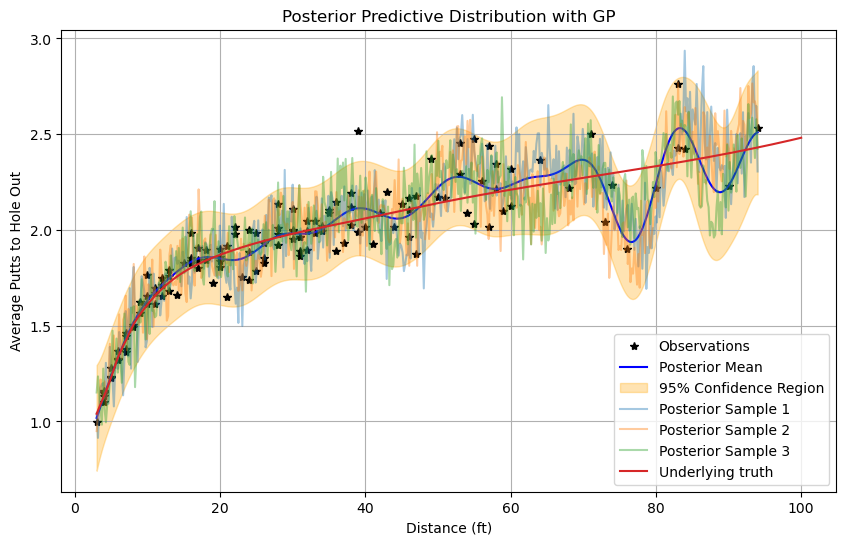

In [44]:
# Where we are going to evaluate these
x_test = torch.linspace(train_x.min(), train_x.max(), 500).unsqueeze(1)

# Set model in eval mode
model.eval()
likelihood.eval()

# Prior samples, before training
with torch.no_grad():
    prior_dist = model(x_test)
    prior_samples = prior_dist.sample(torch.Size([3]))

# Posterior samples after training
with torch.no_grad():
    posterior = likelihood(model(x_test))
    mean = posterior.mean
    lower, upper = posterior.confidence_region()
    posterior_samples = posterior.sample(torch.Size([3]))

# Plot
plt.figure(figsize=(10, 6))

# Training points
plt.plot(train_x.numpy(), train_y.numpy(), 'k*', label='Observations')

# Posterior mean
plt.plot(x_test.numpy(), mean.numpy(), 'b', label='Posterior Mean')

# Confidence interval (±2 std dev)
plt.fill_between(
    x_test.squeeze().numpy(),
    lower.numpy(),
    upper.numpy(),
    alpha=0.3,
    color = "orange",
    label='95% Confidence Region'
)

# Posterior samples
for i in range(3):
    plt.plot(x_test.numpy(), posterior_samples[i].numpy(), alpha=0.4, label=f'Posterior Sample {i+1}')
plt.plot(x_true, y_true, label = "Underlying truth")
plt.legend()
plt.title("Posterior Predictive Distribution with GP")
plt.xlabel("Distance (ft)")
plt.ylabel("Average Putts to Hole Out")
plt.grid(True)
plt.show()


## 'Slicing' to evaluate GPR at different points

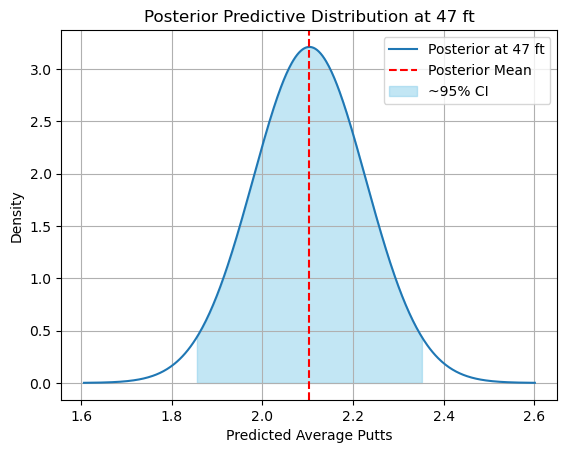

In [46]:
from scipy.stats import norm

# Distance at which to evaluate the posterior
value_to_check = 47
x_query = torch.tensor([[value_to_check]])  # GP requires input shape [n, d]

# Set model and likelihood to evaluation mode 
model.eval()
likelihood.eval()

# Compute posterior predictive distribution at the given input
with torch.no_grad():
    pred_dist = likelihood(model(x_query))  # Returns a MultivariateNormal object
    mu = pred_dist.mean.item()              # Extract the predicted mean
    sigma = pred_dist.stddev.item()         # Extract the predicted standard deviation

# Generate y-values across standard deviations for bell curve plotting
y_vals = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
pdf_vals = norm.pdf(y_vals, loc=mu, scale=sigma)  # Evaluate normal density at each point

# Plot the posterior predictive distribution (bell curve)
plt.plot(y_vals, pdf_vals, label=f'Posterior at {x_query.item()} ft')

# Plot vertical line at the mean prediction
plt.axvline(mu, color='red', linestyle='--', label='Posterior Mean')

# Shade the 95% confidence interval (±2σ)
plt.fill_between(
    y_vals,
    pdf_vals,
    where=(y_vals > mu - 2*sigma) & (y_vals < mu + 2*sigma),
    color='skyblue',
    alpha=0.5,
    label='~95% CI'
)

# Final plot formatting
plt.title(f"Posterior Predictive Distribution at {x_query.item()} ft")
plt.xlabel("Predicted Average Putts")
plt.ylabel("Density")
plt.grid(True)
plt.legend()
plt.show()


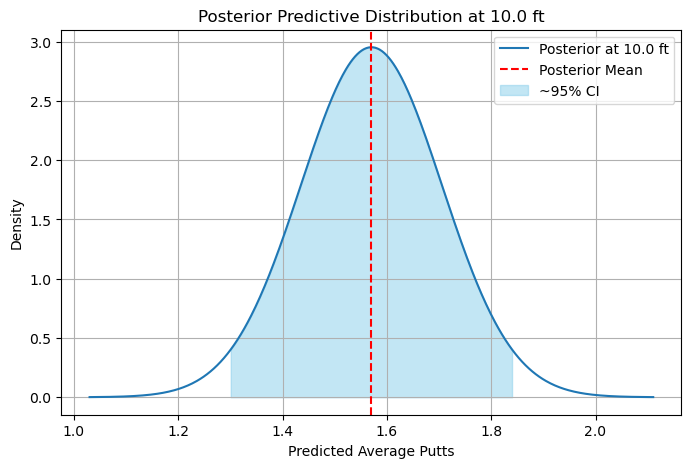

interactive(children=(FloatSlider(value=10.0, description='value_to_check', min=1.0, step=0.5), Output()), _do…

<function __main__.plot_gp_bell_curve(value_to_check)>

In [ ]:
import ipywidgets as widgets
from ipywidgets import interact

def plot_gp_bell_curve(value_to_check):
    x_query = torch.tensor([[value_to_check]], dtype=torch.float32)

    model.eval()
    likelihood.eval()

    with torch.no_grad():
        pred_dist = likelihood(model(x_query))
        mu = pred_dist.mean.item()
        sigma = pred_dist.stddev.item()

    y_vals = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
    pdf_vals = norm.pdf(y_vals, loc=mu, scale=sigma)

    plt.figure(figsize=(8, 5))
    plt.plot(y_vals, pdf_vals, label=f'Posterior at {x_query.item():.1f} ft')
    plt.axvline(mu, color='red', linestyle='--', label='Posterior Mean')
    plt.fill_between(
        y_vals,
        pdf_vals,
        where=(y_vals > mu - 2*sigma) & (y_vals < mu + 2*sigma),
        color='skyblue',
        alpha=0.5,
        label='~95% CI'
    )

    plt.title(f"Posterior Predictive Distribution at {x_query.item():.1f} ft")
    plt.xlabel("Predicted Average Putts")
    plt.ylabel("Density")
    plt.grid(True)
    plt.legend()
    plt.show()

# Create interactive slider from 1 ft to 100 ft
interact(plot_gp_bell_curve, value_to_check=widgets.FloatSlider(min=1.0, max=100.0, step=0.5, value=10.0))
